Nama        : Shenly Lestari Riada 
NPM         : 25083010019 
Link Github : 

Import Library

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns    

Membaca Dataset CSV dan Menampilkan Lima Data Teratas

In [4]:
df = pd.read_csv("dataset_donut.csv")
df.head()

,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


Membaca Informasi Dataset. Berisikan Nama Kolom, Jumlah Data, Pernyataan "non-null" yang Berarti Data Tidak Kosong, dan Tipe data Setiap Kolom

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Tanggal                 450 non-null    str  
 1   Gerai                   450 non-null    str  
 2   Harga Jual (Rp)         450 non-null    int64
 3   Jumlah Terjual (Unit)   450 non-null    int64
 4   Pendapatan Kotor (Rp)   450 non-null    int64
 5   Biaya Variabel (Rp)     450 non-null    int64
 6   Fixed Cost Harian (Rp)  450 non-null    int64
 7   Balance (Rp)            450 non-null    int64
dtypes: int64(6), str(2)
memory usage: 28.3 KB


Menghitung Statistik Data
1.Nilai min dan max dari penjualan (x) sebagai batas awal 
2.Nilai mean untuk menentukan rata-rata penjualan harian

In [6]:
analisis_gerai = ['Jumlah Terjual (Unit)', 'Pendapatan Kotor (Rp)', 'Balance (Rp)']

hasil = (
    df.groupby('Gerai')[analisis_gerai]
    .agg(['min', 'mean', 'max'])
    .round(2)  
)
print(hasil)

        Jumlah Terjual (Unit)              Pendapatan Kotor (Rp)              \
                          min    mean  max                   min        mean   
Gerai                                                                          
Gerai A                    81   99.10  131               2025000  2477500.00   
Gerai B                   435  527.50  710               3480000  4220000.00   
Gerai C                   220  328.93  522               2420000  3618266.67   
Gerai D                   103  149.83  223               2060000  2996666.67   
Gerai E                   153  226.64  332               2295000  3399666.67   

                 Balance (Rp)                       
             max          min        mean      max  
Gerai                                               
Gerai A  3275000      -346833   -48183.00   478167  
Gerai B  5680000       937067  1292267.00  1993067  
Gerai C  5742000      -378133   292896.33  1482187  
Gerai D  4460000     -1348266  -748799.33

HASIL PLOT DAN LINEAR REGRESI
1.Plot "Jumlah Penjualan vs Revenue" 
-Titik-titik biru pada kelima gera membentuk adanya pola naik dan konsisten, dimana banyak donut terjual maka revenue semakin tinggi 
-Tidak terdapat titik yang menyimpang jauh atau outlier dari masing-masing gerai

2.Linear Regresi Bentuk Tren Volume Penjualan
-Linear regresi (Y = aX + b) dipilih karena dari pola scatter, terlihat hubungan lurus dan tidak melengkung 
-R2 = 1.0000 pada seluruh gerai menunjukkan model linear menjelaskan 100% variasi data, membuktikan bahwa hubungan Revenue dan Volume linear terbentuk sempurna
-Perbedaan setiap gerai hanya terletak pada kemiringan garis (slope). Ini berarti setiap gerai memiliki harga jual yang berbeda-beda

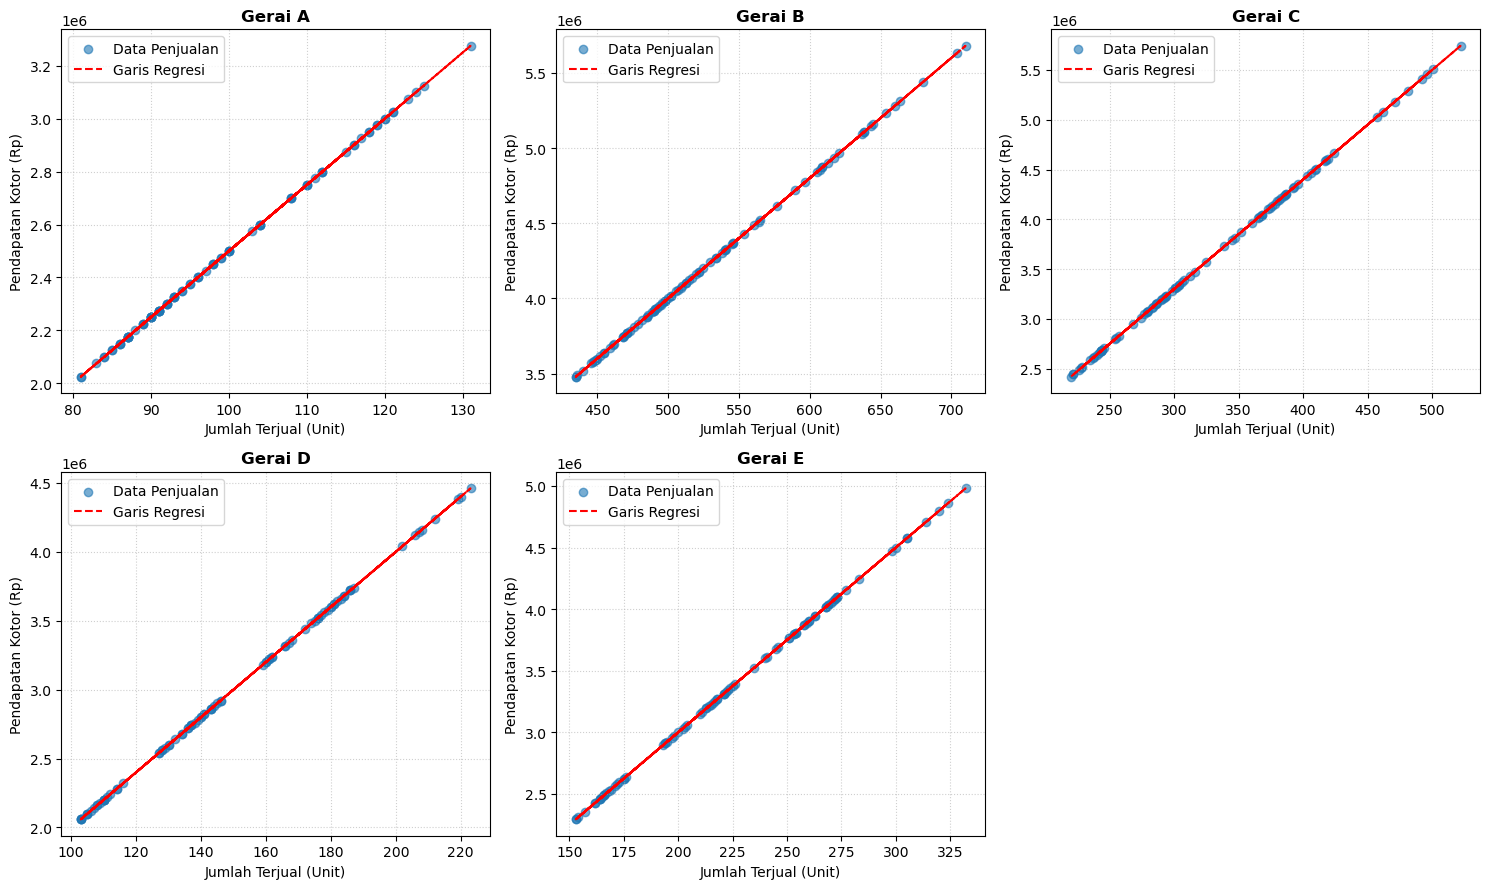

  Gerai   Persamaan Regresi R^2 Score
Gerai A Y = 25,000X + -0.00    1.0000
Gerai B   Y = 8,000X + 0.00    1.0000
Gerai C  Y = 11,000X + 0.00    1.0000
Gerai D  Y = 20,000X + 0.00    1.0000
Gerai E  Y = 15,000X + 0.00    1.0000


In [ ]:
gerai_list = df['Gerai'].unique()
hasil_regresi = []

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, gerai in enumerate(gerai_list):
  sub = df[df['Gerai'] == gerai]
  x = sub['Jumlah Terjual (Unit)'].values
  y = sub['Pendapatan Kotor (Rp)'].values

  a, b = np.polyfit(x, y, deg=1)

  y_pred = a * x + b

  ss_res = np.sum((y - y_pred) ** 2) 
  ss_tot = np.sum((y - np.mean(y)) ** 2) 
  r2 = 1 - (ss_res / ss_tot)

  hasil_regresi.append({
      'Gerai': gerai,
      'Persamaan Regresi': f'Y = {a:,.0f}X + {b:.2f}',
      'R^2 Score': f'{r2:.4f}',
  })

  ax = axes[idx]
  ax.scatter(x, y, alpha=0.6, label='Data Penjualan', color='tab:blue')
  ax.plot(x, y_pred, color='red', linestyle='--', label='Garis Regresi')
  ax.set_title(f'{gerai}', fontsize=12, fontweight='bold')
  ax.set_xlabel('Jumlah Terjual (Unit)')
  ax.set_ylabel('Pendapatan Kotor (Rp)')
  ax.legend(loc='upper left')
  ax.grid(True, linestyle=':', alpha=0.6)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

df_hasil = pd.DataFrame(hasil_regresi)
print(df_hasil.to_string(index=False))

BREAKEVEN POINT

Metode Aljabar
-Berdasarkan data jumlah penjualan dan Balance setiap gerai dengan model linear regresi untuk memperoleh hubungan antara volume penjualan (X) dan Balance (Y)
-Bentuk umum persamaan tersebut, yaitu Y = mX + C 
-Breakeven Point terjadi apabila Balance bernilai nol atau Y = 0 
-Dengan proses subtitus Y = 0 ke dalam persamaan regresi, maka akan diperoleh 0 = mX + c 
-Perhitungan tersebut dilakukan dengan metode aljabar, yaitu mencari nilai X yang menghasilkan nilai Balance sama dengan nol 

Metode Bisection
-Metode lainnya untuk pencarian akar berupa metode Bisection - f(X) = mX + c 
-Nilai keduanya hanya memiliki selisih yang sangat kecil, sehingga pencarian akar metode Bisection ini memberikan hasil konsisten atau sama dengan metode aljabar 

Kesimpulan: 
-Gerai A mencapai sekitar volume penjualan 102,03 atau 103 unit donut 
-Gerai B mencapai sekitar 109,97 atau 191 unit donut 
-Gerai C mencapai sekitar 281,39 atau 282 unit donut 
-Gerai D mencapai sekitar 208,33 atau 209 unit donut 
-Gerai E mencapai sekitar 91,95 atau 92 unit 

In [14]:
def bisection(f, xl, xu, tol=1e-4, max_iter=100):
    for i in range(1, max_iter + 1):
        xr = (xl + xu) / 2

        if abs(f(xr)) < tol or (xu - xl) / 2 < tol:
            return xr, i

        if f(xl) * f(xr) < 0:
            xu = xr
        else:
            xl = xr

    return xr, max_iter

def hitung_bep(data):
    x = data["Jumlah Terjual (Unit)"].to_numpy()
    y = data["Balance (Rp)"].to_numpy()

    # Regresi linear
    m, c = np.polyfit(x, y, 1)

    # metode aljabar
    bep_aljabar = -c / m

    # metode Bisection
    fungsi = lambda x: m * x + c
    bep_bisection, iterasi = bisection(fungsi, 0, 2000)

    return {
        "Gerai": data["Gerai"].iloc[0],
        "Persamaan": f"Y = {m:,.0f}X + ({c:,.0f})",
        "Aljabar": round(bep_aljabar, 2),
        "Bisection": round(bep_bisection, 2),
        "Selisih": round(abs(bep_aljabar - bep_bisection), 5),
        "Iterasi": iterasi,
        "Minimum": int(np.ceil(bep_bisection))
    }

hasil = [
    hitung_bep(data)
    for _, data in df.groupby("Gerai")
]

df_bep = pd.DataFrame(hasil)

print(df_bep.to_string(index=False))

  Gerai                  Persamaan  Aljabar  Bisection  Selisih  Iterasi  Minimum
Gerai A Y = 16,500X + (-1,683,333)   102.02     102.02  0.00002       25      103
Gerai B    Y = 3,840X + (-733,333)   190.97     190.97  0.00001       25      191
Gerai C  Y = 6,160X + (-1,733,333)   281.39     281.39  0.00002       25      282
Gerai D Y = 12,800X + (-2,666,666)   208.33     208.33  0.00003       25      209
Gerai E    Y = 8,700X + (-800,000)    91.95      91.95  0.00003       25       92
